<a href="https://colab.research.google.com/github/sk-shahsi/ML_Model/blob/master/Time_series.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Data Description**

You have been provided with a data set containing daly sales and profit data of the company for the periode 2011 to 2014. the data set has
the following there attributes.




**Attributes	          Description**

**Order-Date**	     The date on which the order was placed (in dd-mm-yyyy format)

**Sales	Total**      sales value of the transaction (in dollars)

**Profit**	         Profit made on the transaction (in dollars)

***Outline***

In the demonstration, we will:

  .Prepare the data for time series modeling

  .forecasting sales using the following models:

    *Autoregressive(AR)

    *Autoregressive integrated
    moving average(ARIMA)

    *Seasonal autoregressive integrated moving average(SARIMA)

  We will analyze the performance of these models using root of the forcasting models using any one of RMSE or MAPE to obtain a more comprehensive assessment of their performance we will use both measures for each models.

**Part 1-Setup and Dta Preparation**

In this section,we will:

  * Import necessary packages for executing the code
  
  *Load the data

  *Prepare the data for futher analysis

  

In [2]:
# Import 'numpy ' and pandas for working with numbers and dataframe
import numpy as np
import pandas as pd

#IMport "pyplot" from matplotlib and seaborn from visualization

from matplotlib import pyplot as plt
import seaborn as sns

# Import and execute methods for suppressing warnings

import warnings
from statsmodels.tools.sm_exceptions import ConvergenceWarning
warnings.simplefilter('ignore', ConvergenceWarning)

Let's begin by loading the data and building familiarity with it.

In [3]:
data = pd.read_csv('Superstore_Data.csv')

In [4]:
data

,Order Date,Sales,Profit
0,17-10-2013,5175.1710,919.9710
1,07-11-2011,1822.0800,564.8400
2,14-04-2012,5244.8400,996.4800
3,06-06-2013,3701.5200,1036.0800
4,25-02-2012,1878.7200,582.3600
...,...,...,...
5694,14-01-2013,38.9709,-32.3991
5695,12-11-2014,6.9000,-0.8400
5696,03-11-2011,17.2800,-13.9200
5697,26-07-2013,30.6180,1.0080


In [5]:
data.head()

,Order Date,Sales,Profit
0,17-10-2013,5175.171,919.971
1,07-11-2011,1822.080,564.840
2,14-04-2012,5244.840,996.480
3,06-06-2013,3701.520,1036.080
4,25-02-2012,1878.720,582.360


In [6]:
data.dtypes

,0
Order Date,object
Sales,float64
Profit,float64


As you can see that data type of the order Date columns is object.but to further conduct analyses on the data,such as grouping by month or year we have to convert the data type of the order date columns to datetime.

In [7]:
data['Order Date'] = pd.to_datetime(data['Order Date'])

/tmp/ipykernel_2406/3021409918.py:1: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  data['Order Date'] = pd.to_datetime(data['Order Date'])


In [8]:
data.dtypes

,0
Order Date,datetime64[ns]
Sales,float64
Profit,float64


Let's make sure that the data points in the data frame are ordered by date.

In [9]:
data.sort_values('Order Date',ascending=True,ignore_index =True,inplace=True)

In [10]:
data.head()

,Order Date,Sales,Profit
0,2011-01-01,55.242,15.342
1,2011-01-01,120.366,36.036
2,2011-01-01,113.670,37.770
3,2011-01-03,912.456,-319.464
4,2011-01-03,6.006,0.546


Next we will set the update Order Date fuature as the index of the data Frame.

In [11]:
data.set_index('Order Date', inplace=True)

In [12]:
data.head()

,Sales,Profit
Order Date,,
2011-01-01,55.242,15.342
2011-01-01,120.366,36.036
2011-01-01,113.670,37.770
2011-01-03,912.456,-319.464
2011-01-03,6.006,0.546


In [13]:
data.iloc[2:5]

,Sales,Profit
Order Date,,
2011-01-01,113.670,37.770
2011-01-03,912.456,-319.464
2011-01-03,6.006,0.546


In [14]:
data.loc['2011-01-01':'2011-03-01']

,Sales,Profit
Order Date,,
2011-01-01,55.2420,15.3420
2011-01-01,120.3660,36.0360
2011-01-01,113.6700,37.7700
2011-01-03,912.4560,-319.4640
2011-01-03,6.0060,0.5460
...,...,...
2011-03-01,91.8720,-45.9480
2011-03-01,12.6360,-1.1640
2011-03-01,238.9290,62.1690


**Note**: When we change the index of the data, then to select the row using new index we should this methods df.loc["new_index"]


To study monthely sales, we need to group the row of df by monthely and sum up the value in each group.We will use the Grouper function in conjunction with the groupby operator for grouping.Grouper is a function in the pandas liberary that allow us to grouping time series data
based on a specification frequency (frq) which in our case is monthaly(M).

In [15]:
data.head()

,Sales,Profit
Order Date,,
2011-01-01,55.242,15.342
2011-01-01,120.366,36.036
2011-01-01,113.670,37.770
2011-01-03,912.456,-319.464
2011-01-03,6.006,0.546


In [16]:
data = data.groupby(pd.Grouper(freq = 'M')).sum()
# 'M' for month same like 'w' is for weeks, 'y' years

/tmp/ipykernel_2406/2028784177.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  data = data.groupby(pd.Grouper(freq = 'M')).sum()


In [17]:
data.shape

(48, 2)

You can see that onaly data from each month is used in the index as representative of each of those months.

Recall from the problem statement that we are interested in forecasting Sales. So we can drop the profit feature from our data sets.

In [18]:
data.head()

,Sales,Profit
Order Date,,
2011-01-31,15711.7125,991.2825
2011-02-28,12910.8588,1338.8688
2011-03-31,19472.5632,3747.1632
2011-04-30,15440.3046,3846.4746
2011-05-31,24348.9723,3639.9423


In [19]:
data.drop(columns='Profit', inplace=True)

In [20]:
data.head()

,Sales
Order Date,
2011-01-31,15711.7125
2011-02-28,12910.8588
2011-03-31,19472.5632
2011-04-30,15440.3046
2011-05-31,24348.9723


Let's now plot our data set to visualize our time series and try to identiy patterns in it..

<Axes: xlabel='Order Date'>

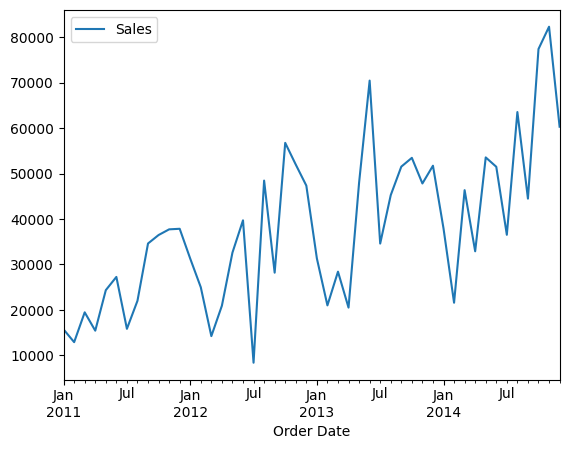

In [21]:
data.plot()

**Now We have 4 main properties in the time series data**

1.Trend:Upward or downward

2.Seasonality: A repeating pattern at a constant time interval.

3.Cyclic nature: A repeating pattern at random time intervals.

4.Noise: Somthing random, you can't explain.

***Part 2*** - **Stationary Analysis**

in this part of the demonstration, we will perform tests on the time series data to understand it is statonary or not. the autoregressive modeling requires the time series data to be statonary. To test this, we will use the following test:

   .Augmented Dickey-Fuller(ADF) Test

***ADF Test***

In [22]:
from statsmodels.tsa.stattools import adfuller

In [23]:
result = adfuller(data['Sales'])

/tmp/ipykernel_2406/267907174.py:1: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  result = adfuller(data['Sales'])


**Note that the null hypothesis for the ADF Testing is The time series is not stationary**

In [24]:
result[1]

0.1987628396941693

***If p Value is<0.5, then our data is statonary otherwise our data is not-statonary


We have analyzed our time series data.let's now split the data into traning and testing set so that we're ready to build and evaluate time series model on the data.

In [25]:
data.head()

,Sales
Order Date,
2011-01-31,15711.7125
2011-02-28,12910.8588
2011-03-31,19472.5632
2011-04-30,15440.3046
2011-05-31,24348.9723


In [26]:
df_train = data[0:42]
df_test = data[42:48]

Text(0.5, 1.0, 'Sales Data')

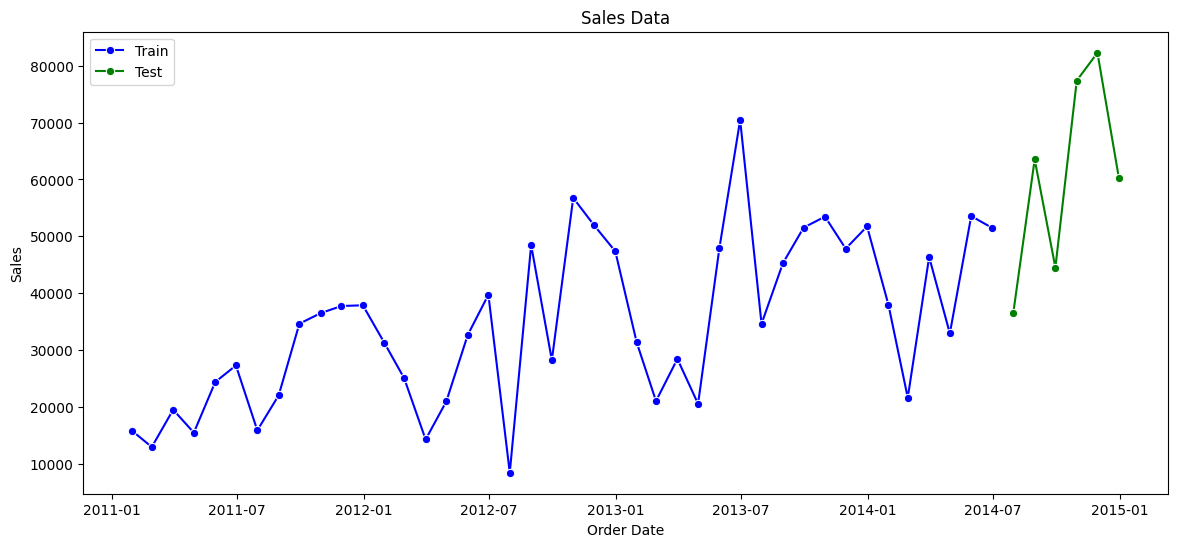

In [27]:
#plot the time seriesdata with the train-test split

plt.figure(figsize=(14,6))
sns.lineplot(data = df_train,x='Order Date', y='Sales',marker = 'o',color='blue',label='Train')
sns.lineplot(data = df_test,x='Order Date',y= 'Sales',marker = 'o',color='green',label='Test')
plt.title('Sales Data')

***Part 3 - Time Series Transformation***

Now we will transform the time series data so we ends up having a more statonary mean and variance. To do this we will use the following data transformations:

  .Box-Cox transformation-makes the varience constance in any time series data

  .Differenceing -make the mean constance in any time series data


  Box-cox transformarion is used to make the varience of a time series statonary and
  differanceing is used to make its means statonary.Note that althrough these methods can be executed any order,differencing is done after Box-cox transformation in general.

  

**3.1- Box-coxTransformation**

The Box-Cox transformation is used to stabilize the varience of a time series it involved the application of a power transformation to the time series data.lets improve the boxcox methods fro scipy to implementation this transformation.

In [28]:
df_train['Sales'].head()

,Sales
Order Date,
2011-01-31,15711.7125
2011-02-28,12910.8588
2011-03-31,19472.5632
2011-04-30,15440.3046
2011-05-31,24348.9723


In [29]:
# import the boxcox method from 'scipy to implements the Box-cox transformation'
from scipy.stats import boxcox

**Note that from here on out we will onaly perform data transformations on the traning data to avoid data leakege.

In [30]:
df_boxcox = pd.Series(boxcox(df_train['Sales'],lmbda = 0),index = df_train.index)


In [31]:
df_boxcox.head()

,0
Order Date,
2011-01-31,9.662162
2011-02-28,9.465824
2011-03-31,9.876762
2011-04-30,9.644737
2011-05-31,10.100245


Text(0.5, 0.98, 'Sales Data')

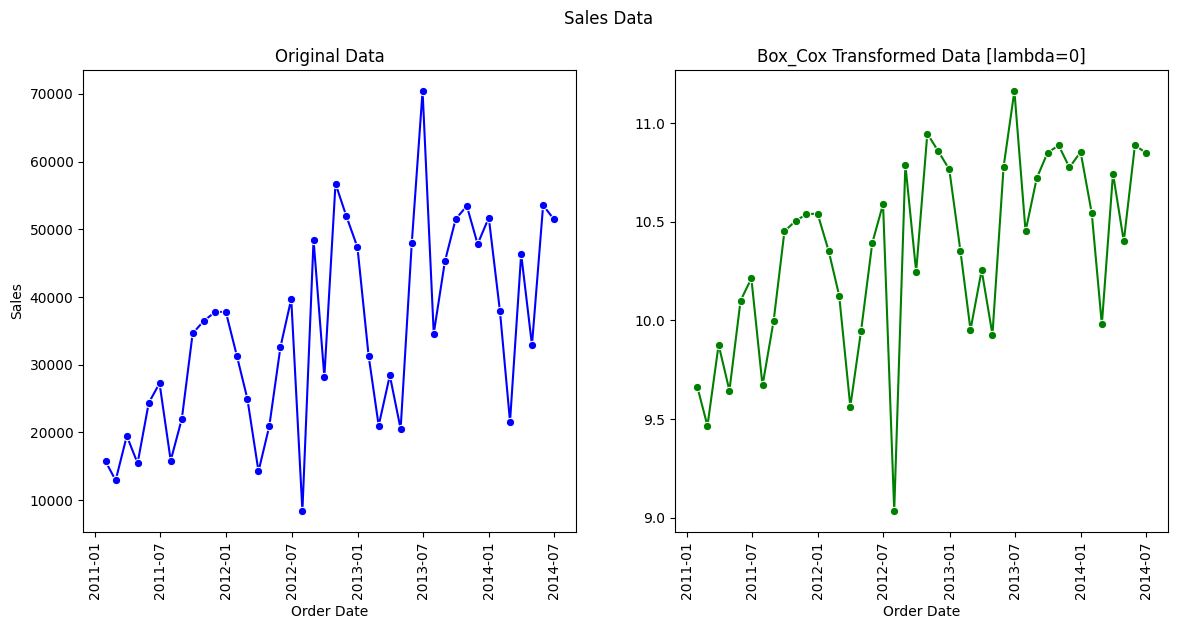

In [32]:
# Plot the original time series and its Box-cox transfer version.

plt.figure(figsize=(14,6))

plt.subplot(1,2,1)

sns.lineplot(data=df_train,x='Order Date',y='Sales',marker = 'o',color = 'blue')
plt.xticks(rotation=90)
plt.title("Original Data")

plt.subplot(1,2,2)

sns.lineplot(x=df_boxcox.index,y=df_boxcox.values,marker = 'o',color = 'green')
plt.xticks(rotation=90)
plt.title("Box_Cox Transformed Data [lambda=0]")

plt.suptitle('Sales Data')


3.2 ** Differencing**

Differencing is used to stabilize the mean of a time series of a time series. it involves talking the differance of consecutive data points in the time series. if the process is executed once, it is known as first-order differencing. if done towice,it is done towice, it is called second -order differencing. And so on

In [33]:
df_train['Sales'].head(6)

,Sales
Order Date,
2011-01-31,15711.7125
2011-02-28,12910.8588
2011-03-31,19472.5632
2011-04-30,15440.3046
2011-05-31,24348.9723
2011-06-30,27260.0196


In [35]:
df_differenced = df_train['Sales'].diff()

Not that Differencing results in a missing value at the beginning of the series, but this is not of much consesequence for the analysis.

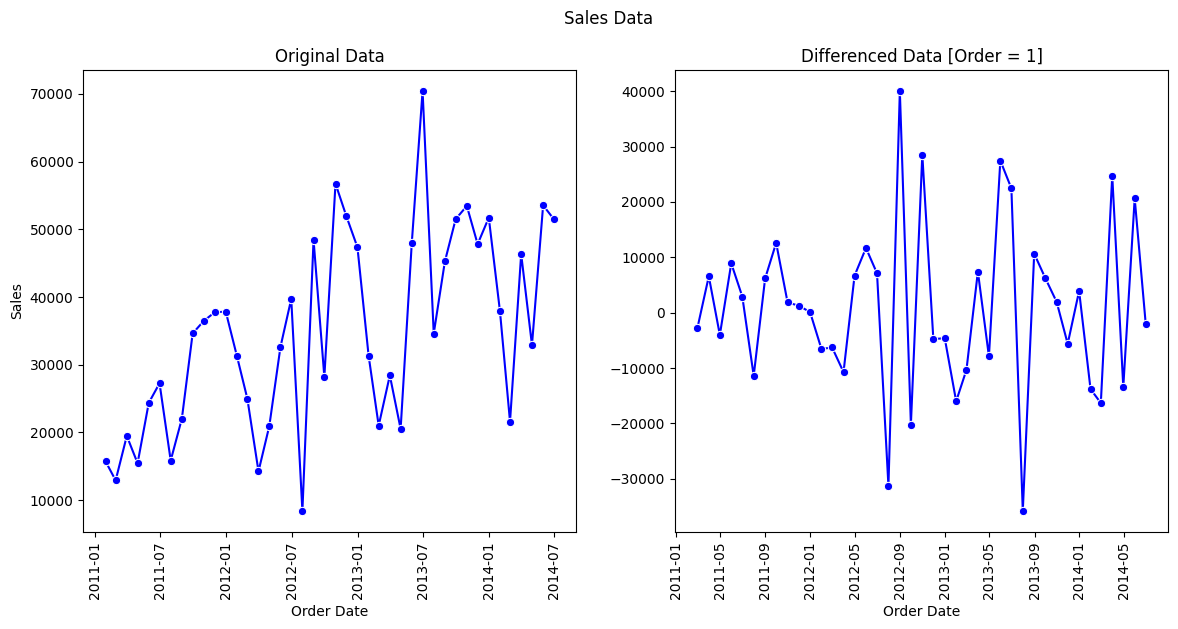

In [36]:
# Plot the original time series data and its first-order differenced version
plt.figure(figsize = (14, 6))

plt.subplot(1, 2, 1)
sns.lineplot(data = df_train, x = 'Order Date', y = 'Sales', marker = 'o', color = 'blue')
plt.xticks(rotation = 90)
plt.title('Original Data')

plt.subplot(1, 2, 2)
sns.lineplot(x = df_differenced.index, y = df_differenced.values, marker = 'o', color = 'blue')
plt.xticks(rotation = 90)
plt.title('Differenced Data [Order = 1]')

plt.suptitle('Sales Data');

We will continue with difference order = 1 for the remaning of the demonstration. However you are free to analyze the impact of other order value on the mean of the time series data.


**3.3 Box-Cox(log)+ Differencing Transformation**

We will now apply the Box-Cox and the differencing transformations on the traning data so the data is ready for autoregressive time

In [37]:
df_boxcox=pd.Series(boxcox(df_train['Sales'],lmbda=0),index = df_train.index)
df_boxcox_diff = df_boxcox.diff()

Text(0.5, 0.98, 'Sales Data')

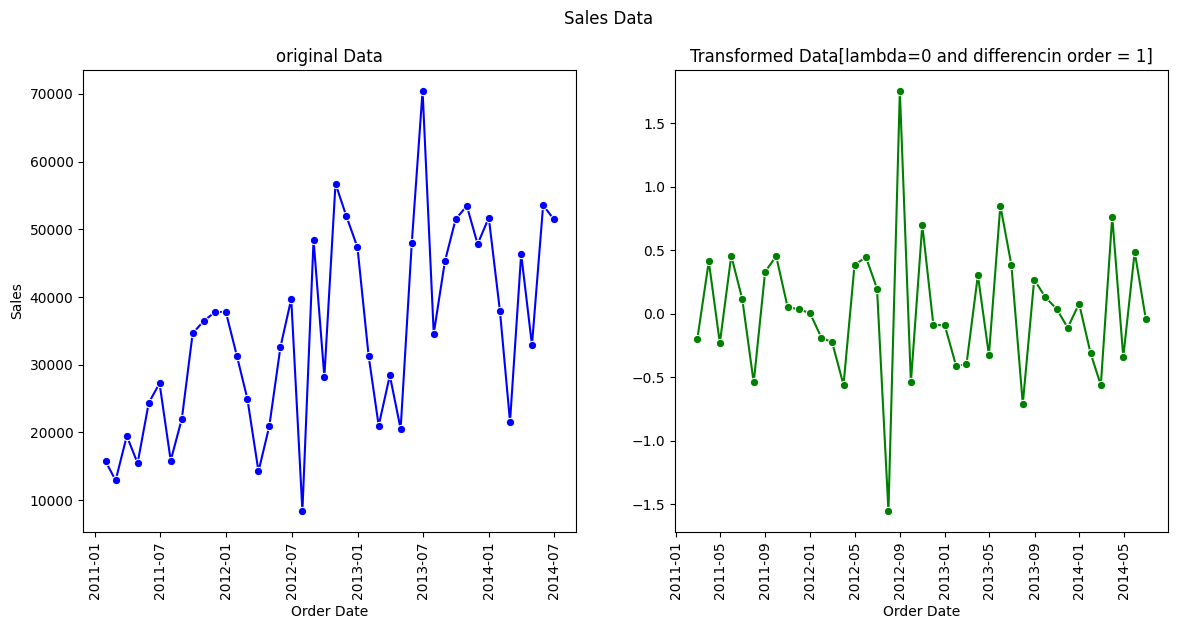

In [38]:
# plot the original time series data and its transformaed version

plt.figure(figsize=(14,6))

plt.subplot(1,2,1)
sns.lineplot(data=df_train,x='Order Date',y='Sales',marker = 'o',color = 'blue')
plt.xticks(rotation=90)
plt.title("original Data")

plt.subplot(1,2,2)
sns.lineplot(x=df_boxcox_diff.index,y=df_boxcox_diff.values,marker = 'o',color = 'green')
plt.xticks(rotation=90)
plt.title("Transformed Data[lambda=0 and differencin order = 1]")

plt.suptitle('Sales Data')

**Run the Adufuller test on the data, again after transformation to check weather our data has become stationary or not.**


   .df_boxcox_diff is the variable where we have that version of our Sales data which has gone through BoxCox transformation and differencing both.

we take df_boxcox_diff[1:] becouse the first value is null so we are ignoring the forst value and runing the test on the rest of the values.

In [39]:
adfuller(df_boxcox_diff[1:])[1]  #p_value of the adfular test after the transformation

/tmp/ipykernel_2406/3502346262.py:1: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  adfuller(df_boxcox_diff[1:])[1]  #p_value of the adfular test after the transformation


7.4522117377521425e-06

**Time Series Decomposition before and after transformation**

<Axes: xlabel='Order Date'>

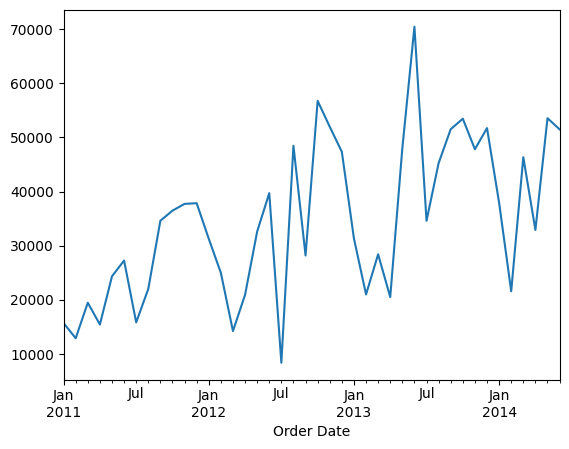

In [40]:
df_train['Sales'].plot()

**1. Seasonal Decomposition of the data before transformation**

In [41]:
from statsmodels.tsa.seasonal import seasonal_decompose

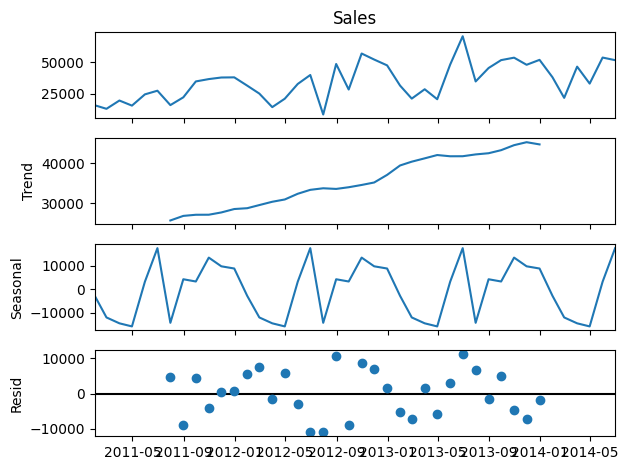

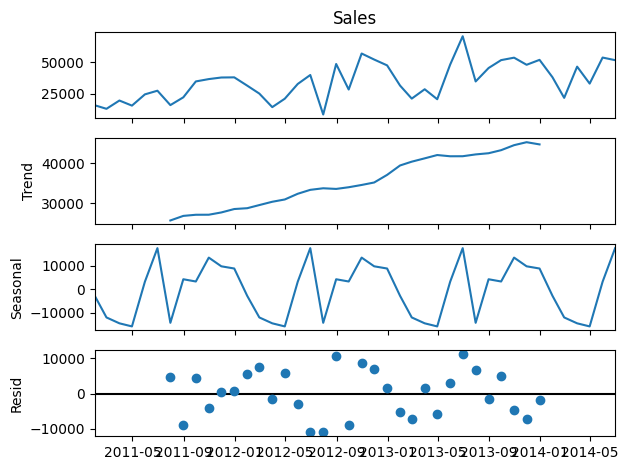

In [42]:
seasonal_decompose(df_train['Sales']).plot()

**2. Seasonal Decomposition of the data after transformation**

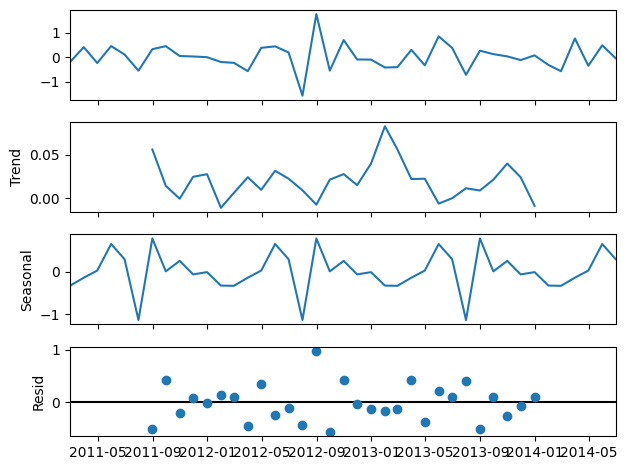

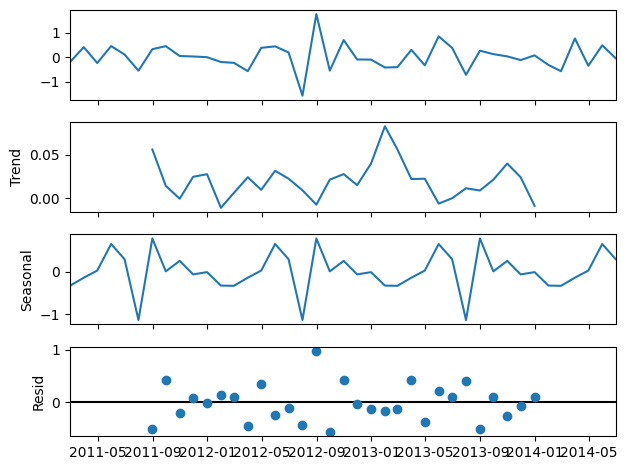

In [43]:
seasonal_decompose(df_boxcox_diff[1:]).plot()

**Part 4 - Autocorrelation Plots**

in this part of the demonstration we will compute and visualize the autocorrelation function(ACF) and the partial autocorrelation function(PACF) plots for the time series data.

**Subpart 1 - Autocorrelation Function (ACF) Plot

The autocorellation function (ACF) plot show the autocorrelation values of a time series for different lag orders.Lets import the plot_act methods from statsmodeles to implements this.

In [44]:

# import 'plot_acf' from statsmodels to compute and visualize the autocorellation function (ACF) for the time series
from statsmodels.graphics.tsaplots import plot_acf

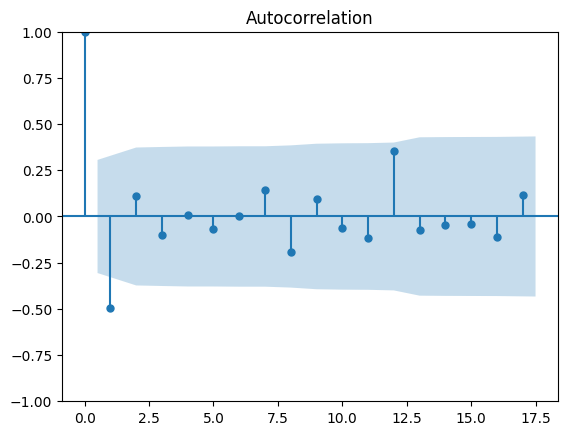

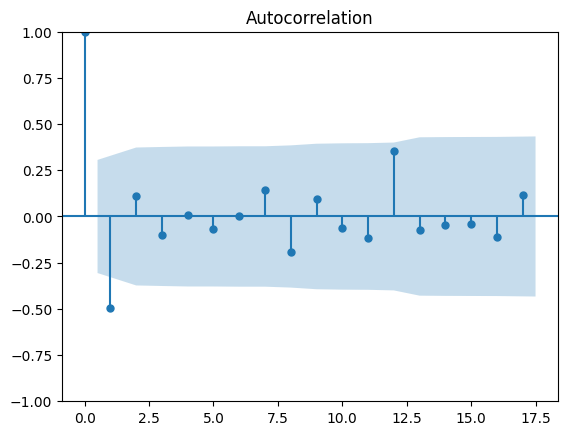

In [46]:
# Note: Since differencing results in a missing value at the beginning, we must exclude it
plot_acf(df_boxcox_diff[1:])

** We can see a strong autocorrelation value at lag order = 1.
There is other lag order value where it is strong as well, such as 11, but 1 is the strongest.

in simple words, ACF measures the correlation between a time series with its lagged value.

if you have daily stock prices, the autocorrelation at lag 1 would measured how today's stock pric related to yesterday ttock price.


**Subplot 2 - Partial Autocoorrelation Function (PACF) Plot**

The partial autocorrelation fucntion (PACF) plot shows the partial autocorrelation values of a time series for different lag orders. Partial autocorrelation is computed such that it ignores short-term correlations in the data. Let's import the plot_pacf method from statsmodels to implement this.

In [47]:
# Import 'plot_pacf' from 'statsmodels' to compute and visualize the partial autocorrelation function (ACF) for the time series
from statsmodels.graphics.tsaplots import plot_pacf

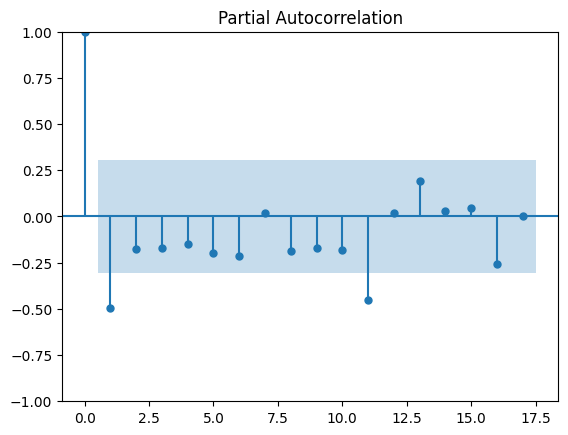

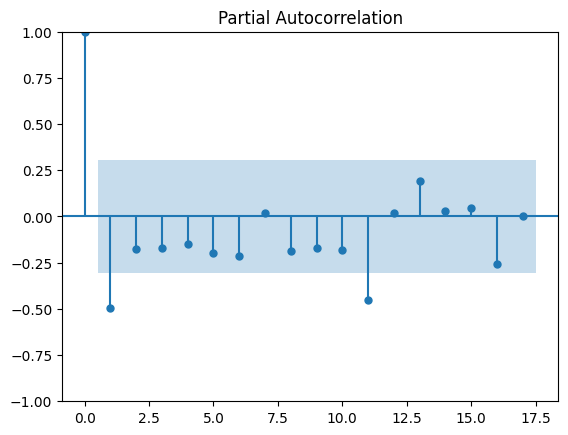

In [48]:
plot_pacf(df_boxcox_diff[1:])

** Calculate AIC and BIC for optimal p and q values**

In [50]:
import statsmodels.api as sm

order_aic_bic = []
#loop over p value from 0-2

for p in range(3):
  #Loop over q value from 0-2

  for q in range(3):
    try:
      # create and fit ARMA(P,Q) model
      model = sm.tsa.statespace.SARIMAX(data['Sales'],order=(p,0,q))
      results = model.fit()
      #print order and results
      order_aic_bic.append((p,q,results.aic,results.bic))
    except:
      print(p,q, None, None)

#Make Dtaframe of model order and AIC/BIC scores
  order_df=pd.DataFrame(order_aic_bic,columns=['p','q','aic','bic'])

  #let's sort them by AIC and BIC

  print("Sorted by AIC: ")
  print("\n")

  print(order_df.sort_values('aic').reset_index(drop=True))

  print("\n")

  print("Sorted by BIC: ")
  print("\n")

  print(order_df.sort_values('bic').reset_index(drop=True))


  #Sort by BIC
  print("\n")
  print("Sorted by BIC:")
  print("\n")

  print(order_df.sort_values('bic').reset_index(drop=True))


Sorted by AIC: 


   p  q          aic          bic
0  0  2  1133.919119  1139.532722
1  0  1  1136.980739  1140.723141
2  0  0  1159.086086  1160.957287


Sorted by BIC: 


   p  q          aic          bic
0  0  2  1133.919119  1139.532722
1  0  1  1136.980739  1140.723141
2  0  0  1159.086086  1160.957287


Sorted by BIC:


   p  q          aic          bic
0  0  2  1133.919119  1139.532722
1  0  1  1136.980739  1140.723141
2  0  0  1159.086086  1160.957287
Sorted by AIC: 


   p  q          aic          bic
0  1  1  1061.306842  1066.920445
1  1  2  1063.570764  1071.055568
2  1  0  1071.820241  1075.562643
3  0  2  1133.919119  1139.532722
4  0  1  1136.980739  1140.723141
5  0  0  1159.086086  1160.957287


Sorted by BIC: 


   p  q          aic          bic
0  1  1  1061.306842  1066.920445
1  1  2  1063.570764  1071.055568
2  1  0  1071.820241  1075.562643
3  0  2  1133.919119  1139.532722
4  0  1  1136.980739  1140.723141
5  0  0  1159.086086  1160.957287


Sorted by BIC:


  

/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/statespace/mlemodel.py:679: EstimationWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  start_params = self.start_params
/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/statespace/mlemodel.py:679: EstimationWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  start_params = self.start_params
/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/statespace/mlemodel.py:679: EstimationWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  start_params = self.start_params


Sorted by AIC: 


   p  q          aic          bic
0  1  1  1061.306842  1066.920445
1  2  1  1062.862845  1070.347649
2  1  2  1063.570764  1071.055568
3  2  0  1063.671028  1069.284631
4  2  2  1065.328869  1074.684874
5  1  0  1071.820241  1075.562643
6  0  2  1133.919119  1139.532722
7  0  1  1136.980739  1140.723141
8  0  0  1159.086086  1160.957287


Sorted by BIC: 


   p  q          aic          bic
0  1  1  1061.306842  1066.920445
1  2  0  1063.671028  1069.284631
2  2  1  1062.862845  1070.347649
3  1  2  1063.570764  1071.055568
4  2  2  1065.328869  1074.684874
5  1  0  1071.820241  1075.562643
6  0  2  1133.919119  1139.532722
7  0  1  1136.980739  1140.723141
8  0  0  1159.086086  1160.957287


Sorted by BIC:


   p  q          aic          bic
0  1  1  1061.306842  1066.920445
1  2  0  1063.671028  1069.284631
2  2  1  1062.862845  1070.347649
3  1  2  1063.570764  1071.055568
4  2  2  1065.328869  1074.684874
5  1  0  1071.820241  1075.562643
6  0  2  1133.919119  113

/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/statespace/mlemodel.py:679: EstimationWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  start_params = self.start_params
/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/statespace/mlemodel.py:679: EstimationWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  start_params = self.start_params


**Part 5 - Autoregressive Models**

in this part of the demonstration, we will fit autoregressive models to the data and anaylze their performance using RMSE and MAPE
values we will build the following models:

  .Autoregressive(AR)
  .Autoregressive integrated moving average (ARIMA)
  .Seasonal autoregressive integrated moving average (SARIMA)

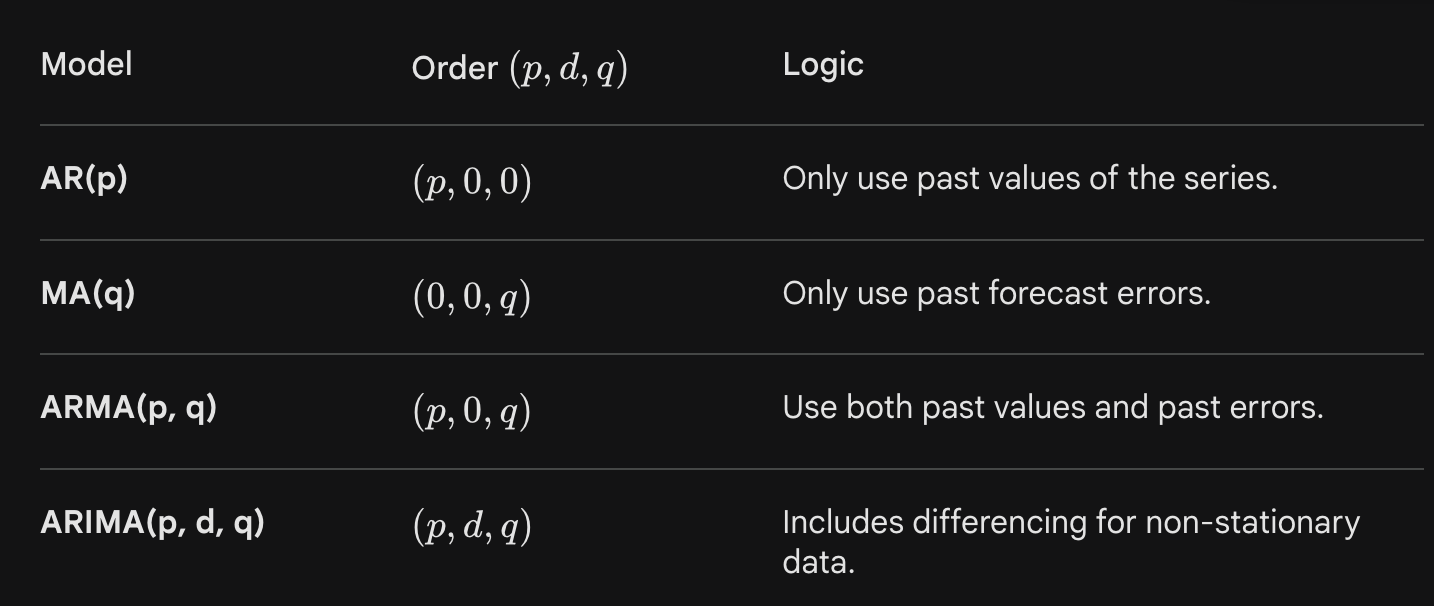

**Subpart-1 Autoregressiive(AR) Method**

We will being by fitted a basic autoregressive model to the training data analyze its performance. we will use the ARIMA methods from statsmodels to build the model.

Note: The ARIMA method can also be used to implement other autoregressive models.

Let's import the ARIMA method from statsmodels.

In [51]:
# import 'Arima ' from statsmodel for building autoregressive models
from statsmodels.tsa.arima.model import ARIMA

In [52]:
# Fit an AR model to the transformed training data with lag order 1 and view its optimal parameter values
# Note: You may try other suitable lag order values as well

ar_model = ARIMA(df_boxcox_diff,order=(1,0,0))
ar_model = ar_model.fit()

In [53]:
# Obtain predictions from the AR model for the testing data indices
train_len =42
ar_model_preds = ar_model.predict(start = train_len, end = len(data) - 1)

In [54]:
ar_model_preds

,predicted_mean
2014-07-31,0.065469
2014-08-31,0.014786
2014-09-30,0.039315
2014-10-31,0.027443
2014-11-30,0.033189
2014-12-31,0.030408


In [55]:
df_test

,Sales
Order Date,
2014-07-31,36524.3028
2014-08-31,63521.7729
2014-09-30,44477.2662
2014-10-31,77379.8286
2014-11-30,82286.3583
2014-12-31,60292.1310


In [56]:
np.log(7)

np.float64(1.9459101490553132)